In [1]:
from ultralytics import YOLO

model = YOLO("yolo26n-pose.pt")

In [ ]:
model


YOLO(
  (model): PoseModel(
    (model): Sequential(
      (0): Conv(
        (conv): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(16, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (1): Conv(
        (conv): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (2): C3k2(
        (cv1): Conv(
          (conv): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
          (act): SiLU(inplace=True)
        )
        (cv2): Conv(
          (conv): Conv2d(48, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_running_stats

In [2]:
import visualtorch
from collections import defaultdict

import matplotlib.pyplot as plt
import visualtorch
from torch import nn

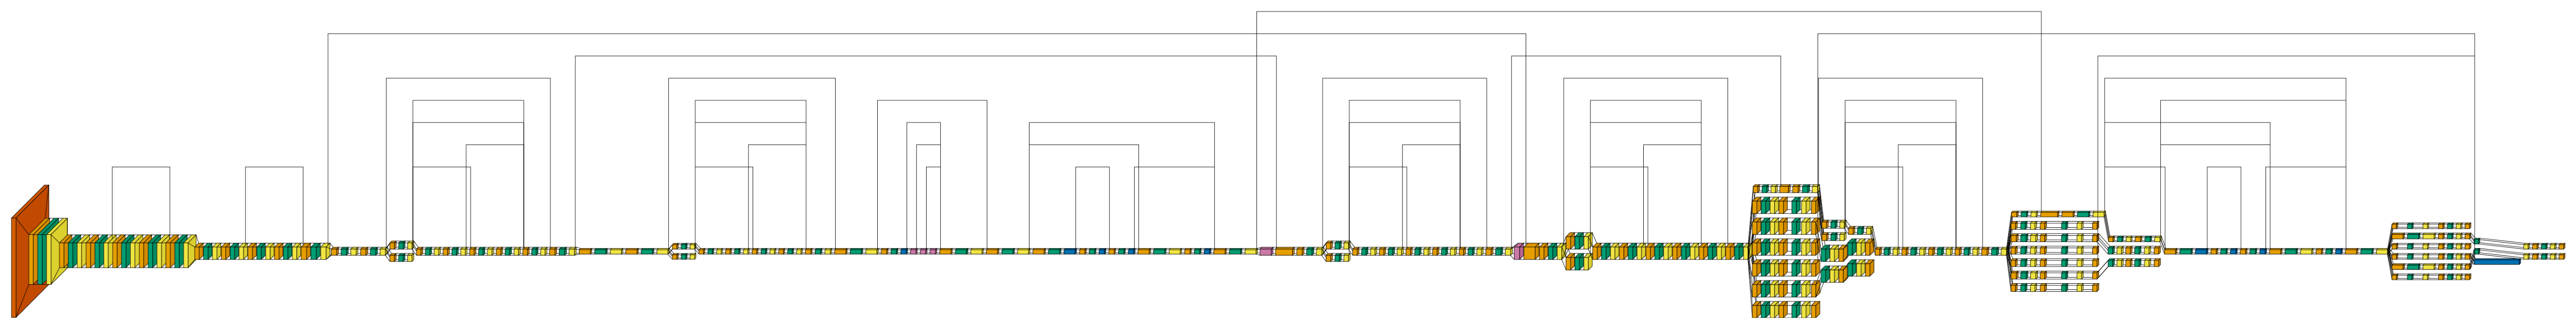

In [3]:

color_map: dict = defaultdict(dict)
color_map[visualtorch.Input]["fill"] = "#D55E00"  # vermillion
color_map[nn.Conv2d]["fill"] = "#E69F00"  # orange
color_map[nn.ReLU]["fill"] = "#56B4E9"  # sky blue
color_map[nn.MaxPool2d]["fill"] = "#CC79A7"  # reddish purple
color_map[nn.Flatten]["fill"] = "#009E73"  # bluish green
color_map[nn.Linear]["fill"] = "#0072B2"  # blue

input_shape = (1, 3, 224, 224)
img = visualtorch.render(model.__dict__["_modules"]["model"], input_shape=input_shape, style="flow", color_map=color_map)

dpi = 150  # rendered at 2x this in the final doc build (savefig.dpi=300 in conf.py)
plt.figure(figsize=(img.width / dpi, img.height / dpi), dpi=dpi)
plt.imshow(img)
plt.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
##TODO: CHECK WHICH POINT MAPS TO WHICH

results = model.predict("/home/mahmoud-sayed/Desktop/wider_10008.jpg")

# Draw bounding boxes + keypoints
annotated = results[0].plot()

# Display
from PIL import Image
Image.fromarray(annotated).show()


image 1/1 /home/mahmoud-sayed/Desktop/wider_10008.jpg: 384x640 3 persons, 68.7ms
Speed: 2.3ms preprocess, 68.7ms inference, 0.5ms postprocess per image at shape (1, 3, 384, 640)


In [ ]:
results[0].keypoints

ultralytics.engine.results.Keypoints object with attributes:

conf: tensor([[0.9978, 0.9926, 0.9997, 0.0156, 0.9945, 0.9893, 0.9677, 0.6937, 0.6145, 0.2089, 0.8198, 0.5184, 0.2895, 0.0176, 0.0088, 0.0032, 0.0012],
        [0.9965, 0.9996, 0.9978, 0.9788, 0.5147, 0.9870, 0.9811, 0.9451, 0.5304, 0.9093, 0.3026, 0.5597, 0.4959, 0.0180, 0.0162, 0.0034, 0.0037],
        [0.9976, 0.9997, 0.9837, 0.9941, 0.0117, 0.9494, 0.9893, 0.2207, 0.6267, 0.0811, 0.0819, 0.2040, 0.3085, 0.0088, 0.0183, 0.0018, 0.0027]])
data: tensor([[[3.1676e+02, 1.4006e+02, 9.9781e-01],
         [3.3994e+02, 9.6231e+01, 9.9257e-01],
         [2.7001e+02, 1.0432e+02, 9.9970e-01],
         [3.5980e+02, 7.3272e+01, 1.5576e-02],
         [1.6282e+02, 9.0235e+01, 9.9454e-01],
         [3.6559e+02, 1.8734e+02, 9.8925e-01],
         [5.4080e+01, 2.3162e+02, 9.6775e-01],
         [3.6069e+02, 3.5987e+02, 6.9375e-01],
         [3.5345e+01, 4.1286e+02, 6.1446e-01],
         [2.7886e+02, 4.0605e+02, 2.0889e-01],
         [2.1603e